In this notebook, we explore the dynamics of the "Smart-Predict then Optimize" paper and its proposed surrogate loss function SPO+. Specifically, we explore its performance relative to the tradtiional predict then optimize paradigm with vanilla mean squared error (MSE) prediction loss. Some simple, intentional examples are constructed, to gain some intuition before moving on to more "blackbox" experiments. 

In [1]:
import pyepo
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch import nn
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

In [134]:
#-------------------------------------------------------------------------------------------------
#Helper Functions
#-------------------------------------------------------------------------------------------------
def generate_correlated_weights(mean_values, rho, target_mean=50, target_std=10):
    """
    Generates weights that have a specific correlation 'rho' with the 'mean_values'.
    
    Args:
        mean_values (Tensor): The average value of each item (shape: [i]).
        rho (float): Target correlation coefficient (-1.0 to 1.0).
        target_mean (float): The desired average weight.
        target_std (float): The desired standard deviation of weights.
    """
    # 1. Standardize the input values (x) to have mean 0 and std 1
    x = mean_values - torch.mean(mean_values)
    x = x / torch.std(x)
    
    # 2. Generate a random vector (y)
    y = torch.randn_like(mean_values)
    
    # 3. Make y orthogonal to x (remove any accidental correlation)
    # Project y onto x: proj = (y . x) / (x . x) * x
    slope = torch.dot(y, x) / torch.dot(x, x)
    y_ortho = y - slope * x
    
    # 4. Standardize the orthogonal vector
    y_ortho = y_ortho - torch.mean(y_ortho)
    y_ortho = y_ortho / torch.std(y_ortho)
    
    # 5. Combine x and y_ortho to get the desired correlation rho
    # w_std will have mean 0, std 1, and correlation rho with mean_values
    w_standard = rho * x + torch.sqrt(torch.tensor(1 - rho**2)) * y_ortho
    
    # 6. Scale and shift to target mean/std
    weights = target_mean + target_std * w_standard
    
    # 7. Post-processing: Ensure weights are positive
    # (Simple clipping or shifting if random generation created negatives)
    if torch.min(weights) <= 0:
        weights -= (torch.min(weights) - 1)
        
    return weights


#Function to take data points and plot scatter plot with optional regression lines
def plot_2d(x, y, xlbl, ylbl, title=None, regression=None):
    plt.scatter(x,y, c='gray')
    if regression is not None:
        x_line = np.array([min(x), max(x)])
        for line in regression: 
            y_line = line['weights'] * x_line + line['bias']
            plt.plot(x_line, y_line, label=line['type'])
        plt.legend()
    plt.xlabel(xlbl)
    plt.ylabel(ylbl)
    plt.title(title)
    plt.show()

#Function to calculate regret
def calc_regret(loader, model, optmodel):
    return pyepo.metric.regret(model, optmodel, loader)

#Function to train models and record statistics
def trainModel(loader_train, loader_test, optmodel, model, criterion, name, epochs=25, lr=1e-1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_loss_log, train_regret_log = [], []
    test_loss_log, test_regret_log = [], []
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        temp_loss = []
        for data in loader_train:
            x, c, w, z = data
            cp = model(x)
            
            loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            temp_loss.append(loss.item())

        # Calculate Training Metrics (Once per epoch)
        train_loss_log.append(np.mean(temp_loss))
        train_regret_log.append(pyepo.metric.regret(model, optmodel, loader_train))

        # --- TESTING ---
        model.eval() # Important for consistency
        temp_loss = []
        with torch.no_grad():
            for data in loader_test:
                x, c, w, z = data
                cp = model(x)
                loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
                temp_loss.append(loss.item())
        
        # Calculate Testing Metrics (Once per epoch)
        test_loss_log.append(np.mean(temp_loss))
        test_regret_log.append(pyepo.metric.regret(model, optmodel, loader_test))

        if epoch % 10 == 0:
            print(f'Epoch: {epoch} Loss Type: {name}')
            print(f'Train Loss {train_loss_log[-1]:.2f} Test Loss {test_loss_log[-1]:.2f}')
            print(f'Train Regret {train_regret_log[-1] *100:.2f}% Test Regret {test_regret_log[-1]*100:.2f}%')
    
    print("-" * 60)
    print(f'End of {name} Training')
    print("-" * 60)

    print(f'Total Epochs: {epochs} Loss Type: {name}')
    print(f'Final Train Loss {train_loss_log[-1]:.2f} Final Test Loss {test_loss_log[-1]:.2f}')
    print(f'Final Train Regret {train_regret_log[-1] *100:.2f}% Final Test Regret {test_regret_log[-1]*100:.2f}%')

    return train_loss_log, test_loss_log, train_regret_log, test_regret_log

#Funtion to plot trajectory of training curves
def plotLearningCurves(train_loss, test_loss, train_regret, test_regret, name):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    epochs = range(len(train_loss))

    # --- Plot 1: Loss (Prediction Error) ---
    ax[0].plot(epochs, train_loss, label='Train Loss', color='blue', lw=2)
    ax[0].plot(epochs, test_loss, label='Test Loss', color='lightblue', linestyle='--')
    ax[0].set_title(f'{name} Loss Trajectory')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss Value')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # --- Plot 2: Regret (Decision Error) ---
    ax[1].plot(epochs, [r * 100 for r in train_regret], label='Train Regret', color='green', lw=2)
    ax[1].plot(epochs, [r * 100 for r in test_regret], label='Test Regret', color='lightgreen', linestyle='--')
    ax[1].set_title(f'{name} Regret Trajectory')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Regret (%)')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#-------------------------------------------------------------------------------------------------
#Models
#-------------------------------------------------------------------------------------------------

#Linear Regression Model
class LinearRegression(nn.Module):
    def __init__(self, num_feat, num_item):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(num_feat, num_item)

    def forward(self, x):
        out = self.linear(x)
        return out
    
    def solve_least_sqaures(self, X, Y):
        lstsq = torch.linalg.lstsq(torch.cat([X, torch.ones(X.shape[0], 1)], dim=1), Y)
        solution = lstsq.solution
        self.linear.weight = nn.Parameter(solution[:-1].T)
        self.linear.bias = nn.Parameter(solution[-1])


#MLP Model
class MLP(nn.Module):
    def __init__(self, num_feat, hidden, num_item):
        super(MLP, self).__init__()
        self.l1 = nn.Linear(num_feat, hidden)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden, num_item)
        
    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out
#Knapsack
class Knapsack():
    def __init__(self, weights, capacity):
        self.num_items = len(weights)
        self.model = gp.Model("knapsack")
        self.model.setParam('OutputFlag', 0)  # Silence Gurobi output
        # Decision variables: x[i] is 1 if item i is selected, 0 otherwise
        self.x = self.model.addVars(self.num_items, vtype=GRB.BINARY, name="x")

        # Constraint: Total weight <= Capacity
        self.model.addConstr(sum(weights[i] * self.x[i] for i in range(self.num_items)) <= capacity, "Capacity")

    def set_objective(self, values):
        self.model.setObjective(sum(values[i] * self.x[i] for i in range(self.num_items)), GRB.MAXIMIZE)
    
    def solve(self):
        self.model.optimize()
        # Extract solution
        if self.model.status == GRB.OPTIMAL:
            selected = [i for i in range(self.num_items) if self.x[i].x > 0.5]
            return selected, self.model.objVal
        else:
            return None

In [ ]:
#Simple Example
#Generate Random Features (num_feat, num_samples)
features = 10 * torch.rand((1,2000))
#Mapping (num_item, num_feat)
item_map = torch.tensor([3, 7, 9.5], dtype=torch.float32).unsqueeze(1)

#Generate Values from item mapping (num_item, num_samples)
values = item_map @ features
#Add Noise to the values
#values += torch.randn_like(values)
#Shift Values so none are at zero
values -= torch.min(values, dim=1, keepdim=True).values

#Add Outliers
values[2] = torch.where(values[2] > 90, values[2] * 10  , values[2])

#Generate Weights (num_item)
weights = torch.tensor([3, 7, 8])

#Set capacity of knapsack
capacity = 10

#Visualize the items
for item in range(len(weights)):
    plot_2d(features[0], values[item,], 'x', 'v', f'Item:{item}')

In [282]:
#Parameters
i = 20 #items
n = 1000 #samples of data
d = 5 #numper of features
p = 2 #power of polynomial cost function
ec = 1.5 #noise multiplier for generating costs
capPCT = 0.3 #capacity of knapsack as a % of total weight

#Generate Random Features
features = 10 * torch.rand((d,n))
#Generate Random Mapping
item_map = torch.randn((i,d))
#Generate Costs
values = (item_map @ features / d) ** p 
#Add Noise to Costs
values += ec * torch.std(values, dim=1, keepdim=True) * torch.randn_like(values)
#Shift Values to have minimum at zero
values -= torch.min(values, dim=1, keepdim=True).values
#Generate Weights
weights = generate_correlated_weights(torch.mean(values, dim=1), rho=0.9, target_mean=torch.mean(values))
#Calculate capacity
capacity = [int(torch.sum(weights) * capPCT)]

Avg. Stdev. of Cost to Weight: 0.71


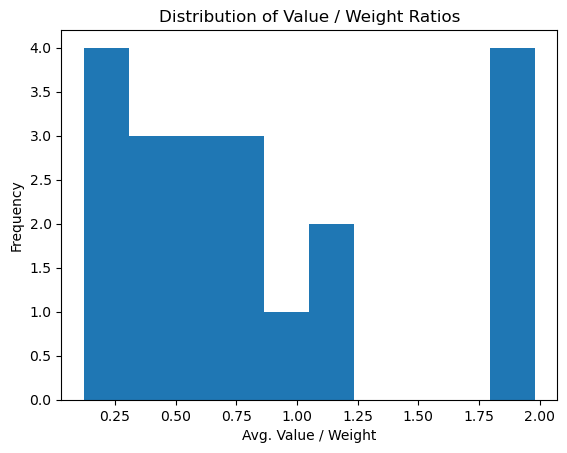

In [283]:
print(f'Avg. Stdev. of Cost to Weight: {torch.mean(torch.std(values / weights.unsqueeze(1), dim=0)):.2f}')
plt.hist(torch.mean(values, dim=1) / weights)
plt.title('Distribution of Value / Weight Ratios')
plt.xlabel('Avg. Value / Weight')
plt.ylabel('Frequency')
plt.show()

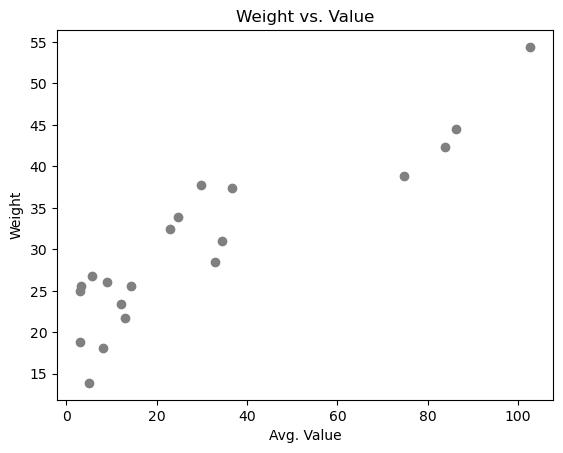

In [284]:
plot_2d(torch.mean(values, dim=1), weights, 'Avg. Value', 'Weight', 'Weight vs. Value')

In [285]:
#Partition Data
#Split Data Into Train / Test
feat_train, feat_test, value_train, value_test = train_test_split(features.T, values.T, test_size= int(features.shape[1] *.2))

#Create Optimization Model Datasets, and Data Loaders
optmodel = pyepo.model.grb.knapsackModel(weights.view(1, -1), capacity)
dataset_train = pyepo.data.dataset.optDataset(optmodel, feat_train, value_train)
dataset_test = pyepo.data.dataset.optDataset(optmodel, feat_test, value_test)

batch_size = 100
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

Optimizing for optDataset...


100%|██████████| 800/800 [00:02<00:00, 297.23it/s]

Optimizing for optDataset...



100%|██████████| 200/200 [00:00<00:00, 212.39it/s]


In [281]:
#"Train" simple Linear Regression with mean squared error
model_mse = LinearRegression(features.shape[0], values.shape[0])
model_mse.solve_least_sqaures(feat_train, value_train)
print("-" * 60)
print(f'End of MSE Training')
print("-" * 60)
print(f'Final Train Regret {calc_regret(loader_train, model_mse, optmodel)*100:.2f}% Final Test Regret {calc_regret(loader_test, model_mse, optmodel)*100:.2f}%')

------------------------------------------------------------
End of MSE Training
------------------------------------------------------------
Final Train Regret 0.18% Final Test Regret 0.21%


Num of cores: 1
Epoch: 0 Loss Type: SPO+
Train Loss 4296.86 Test Loss 4222.30
Train Regret 35.30% Test Regret 34.92%
Epoch: 10 Loss Type: SPO+
Train Loss 2551.99 Test Loss 2515.28
Train Regret 26.30% Test Regret 26.06%
Epoch: 20 Loss Type: SPO+
Train Loss 1748.91 Test Loss 1769.54
Train Regret 4.99% Test Regret 5.49%
Epoch: 30 Loss Type: SPO+
Train Loss 1350.07 Test Loss 1393.84
Train Regret 4.63% Test Regret 5.27%
Epoch: 40 Loss Type: SPO+
Train Loss 1134.15 Test Loss 1183.83
Train Regret 4.24% Test Regret 4.74%
Epoch: 50 Loss Type: SPO+
Train Loss 1011.83 Test Loss 1067.28
Train Regret 4.20% Test Regret 4.82%
Epoch: 60 Loss Type: SPO+
Train Loss 939.62 Test Loss 995.91
Train Regret 4.12% Test Regret 4.72%
Epoch: 70 Loss Type: SPO+
Train Loss 891.46 Test Loss 953.68
Train Regret 4.15% Test Regret 4.82%
Epoch: 80 Loss Type: SPO+
Train Loss 856.92 Test Loss 921.78
Train Regret 4.11% Test Regret 4.73%
Epoch: 90 Loss Type: SPO+
Train Loss 832.09 Test Loss 897.88
Train Regret 4.17% Test Re

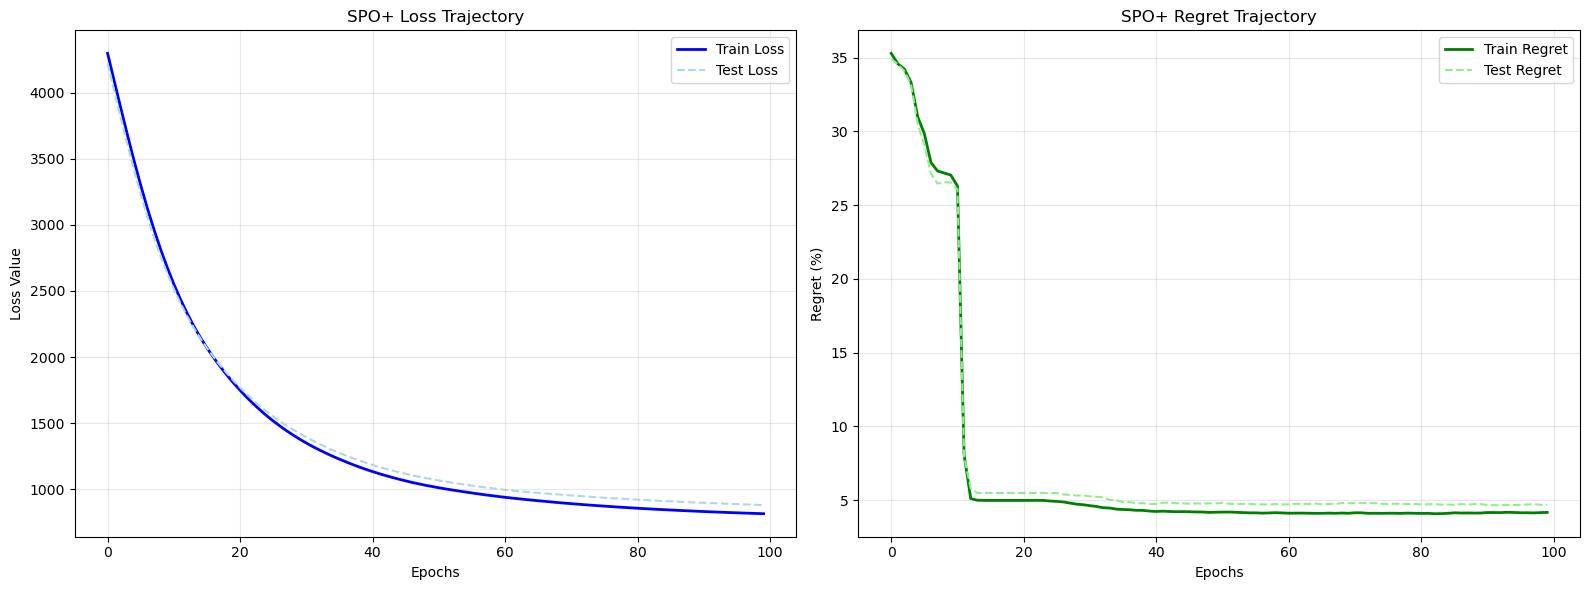

In [235]:
#Train simple Linear Regression with spo+
model_spo = LinearRegression(features.shape[0], values.shape[0])
#Hot start with mse weights
# model_spo.linear.weight = nn.Parameter(model_mse.linear.weight.detach().clone())
# model_spo.linear.bias = nn.Parameter(model_mse.linear.bias.data.detach().clone())
spo = pyepo.func.SPOPlus(optmodel, processes=1)
logs_spo = trainModel(loader_train, loader_test, optmodel, model_spo, spo, "SPO+", epochs=100)
plotLearningCurves(*logs_spo, name="SPO+")

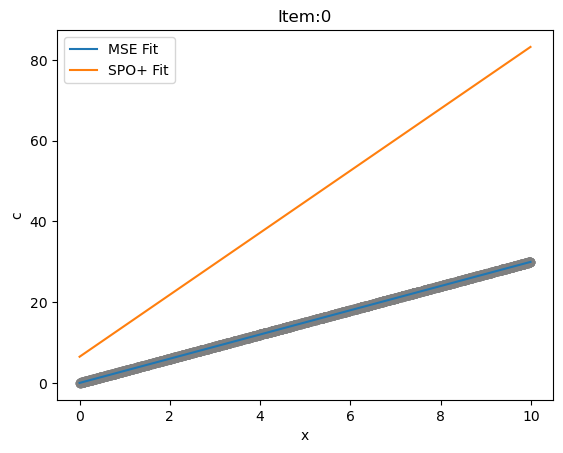

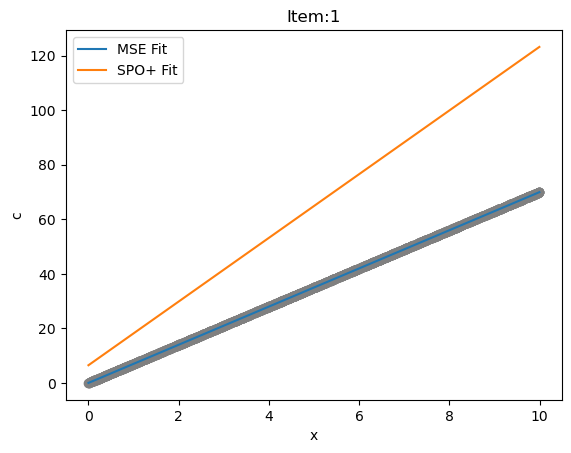

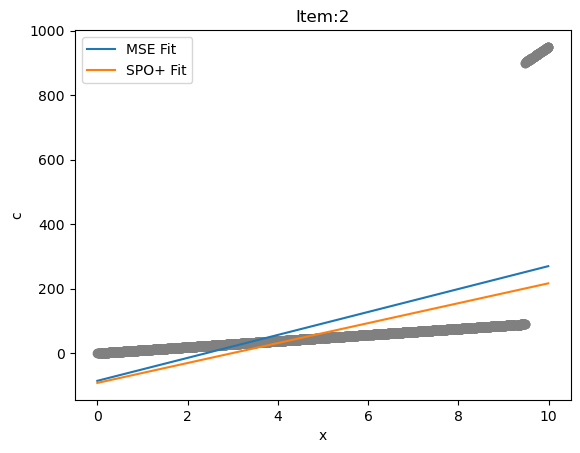

In [ ]:
for item in range(len(weights)):
    fits = [
    {'type' : 'MSE Fit', 'weights' : model_mse.linear.weight.detach()[item], 'bias' : model_mse.linear.bias.detach()[item]},
    {'type' : 'SPO+ Fit', 'weights' : model_spo.linear.weight.detach()[item], 'bias' : model_spo.linear.bias.detach()[item]},
    ]
    plot_2d(features[0], values[item,], 'x', 'v', f'Item:{item}', fits)

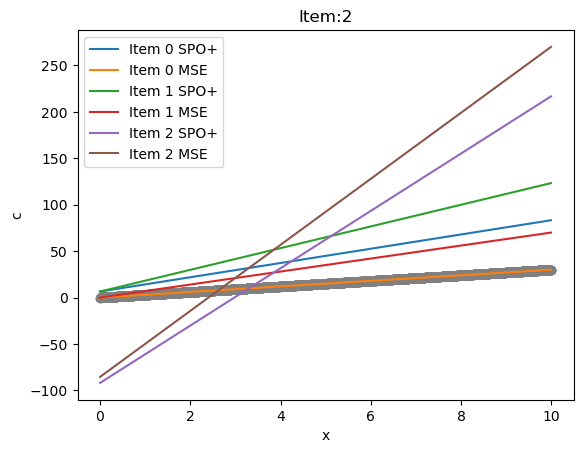

In [93]:
fits = []
for item in range(len(weights)):
    fits.append({'type' : f'Item {item} SPO+', 'weights' : model_spo.linear.weight.detach()[item], 'bias' : model_spo.linear.bias.detach()[item]})
    fits.append({'type' : f'Item {item} MSE', 'weights' : model_mse.linear.weight.detach()[item], 'bias' : model_mse.linear.bias.detach()[item]})
    
plot_2d(features[0], values[0,], 'x', 'c', f'Item:{item}', fits)

In [ ]:
problem = Knapsack(weights, capacity[0])
start = int(torch.min(features).item())
stop = int(torch.max(features).item())

results = []

for x in np.linspace(start + 1, stop + 1, num = 20):
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    optimal = (item_map @ x) ** p 
    #Shift Values to have minimum at zero
    optimal -= torch.min(optimal, dim=0, keepdim=True).values
    mse = model_mse(x).tolist()
    spo = model_spo(x).tolist()

    problem.set_objective(optimal)
    optimal_solution, optimal_objective = problem.solve()

    problem.set_objective(mse)
    mse_solution, mse_objective = problem.solve()

    problem.set_objective(spo)
    spo_solution, spo_objective = problem.solve()
    results.append(
        {
            'Feature (x)' : x.item(),
            'True Optimal Items' : str(optimal_solution),
            'MSE Items' : str(mse_solution),
            'SPO Items' : str(spo_solution),
            # 'Optimal Value' : optimal_objective,
            # 'MSE Value' : mse_objective,
            # 'SPO Value' : spo_objective
        }
    )

df = pd.DataFrame(results)
print(df)
    

In [ ]:
#Parameters
i = 10 #items
n = 1000 #samples of data
d = 1 #numper of features
p = 1 #power of polynomial cost function
ec = 1 #noise multiplier for generating costs
ew = 5 #noise multiplied for generating weights
capPCT = 0.4 #capacity of knapsack as a % of total weight

#Generate Random Features
x = 10 * torch.rand((d,n))
#Generate Random Mapping
A = torch.randn((i,d))
#Generate Costs
c = (A @ x) ** p 
#Add Noise to Costs
c += ec * (torch.mean(c, dim=1, keepdim=True) * torch.rand(i,1) * torch.randn_like(c))
#Shift Values to have minimum at zero
c -= torch.min(c, dim=1, keepdim=True).values
#Generate Weights
w = torch.mean(c, dim=1) + (ew * torch.std(c, dim=1) * torch.randn(i))
w -= torch.min(w) - 1
#Calculate capacity
capacity = [int(torch.sum(w) * capPCT)]
print(w.shape)

torch.Size([10])
